# Individual conditional expectation — module 02

Molnar, *Interpretable Machine Learning*, **chapter 13**.

Module 01 drew one ceteris paribus curve for one patient. An ICE plot is that
same computation run for everybody and drawn in one frame. Molnar puts it
plainly: *"ICE plots are CP plots containing all CP curves for an entire
dataset."*

So the method is not new. The **question** is: what does stacking them tell
you that one curve cannot, and what does averaging them throw away?

Same model, same split, same seed as modules 01 and 03.

In [1]:
%pip install -q scikit-learn matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
BLUE = "#315B86"        # benign
TERRACOTTA = "#C96F3F"  # malignant
DARK = "#252525"
GRAY = "#A8A8A8"

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "figure.dpi": 140})

data = load_breast_cancer()
X_all, y_all = data.data, data.target
feature_names = list(data.feature_names)
feat_idx = {f: i for i, f in enumerate(feature_names)}

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=RANDOM_STATE, stratify=y_all
)
model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE)
model.fit(X_train, y_train)
proba_test = model.predict_proba(X_test)[:, 1]

instance_idx = 67
row = X_test[instance_idx]
train_mean, train_std = X_train.mean(axis=0), X_train.std(axis=0)

FIG_DIR = "figures_generated"  # regenerated on each run; committed copies live in ../figures
os.makedirs(FIG_DIR, exist_ok=True)

J = feat_idx["worst perimeter"]
GRID = np.linspace(X_all[:, J].min(), X_all[:, J].max(), 120)


def ice_curves(X, j, grid):
    """One ceteris paribus curve per row of X. Returns (n_rows, len(grid))."""
    out = np.empty((len(X), len(grid)))
    for i, base in enumerate(X):
        probe = np.tile(base, (len(grid), 1))
        probe[:, j] = grid
        out[i] = model.predict_proba(probe)[:, 1]
    return out


def new_figure(title, figsize=(8.5, 5.4)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", pad=12)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    return fig, ax


def save_figure(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=200, bbox_inches="tight")


ICE = ice_curves(X_test, J, GRID)
PDP = ICE.mean(axis=0)
conf = np.abs(proba_test - 0.5)

print(f"{len(X_test)} test patients × {len(GRID)} grid points = {ICE.size:,} model calls")
print(f"sweeping '{feature_names[J]}' from {GRID.min():.0f} to {GRID.max():.0f}")

143 test patients × 120 grid points = 17,160 model calls
sweeping 'worst perimeter' from 50 to 251


## Step 1 — the bundle, and its average

Every thin line is one patient's ceteris paribus curve. The thick line is
their average, which is the partial dependence plot.

**What to look for.** Not the average — the spread around it. How much do the
thin lines differ from one another, and do any of them run the other way?

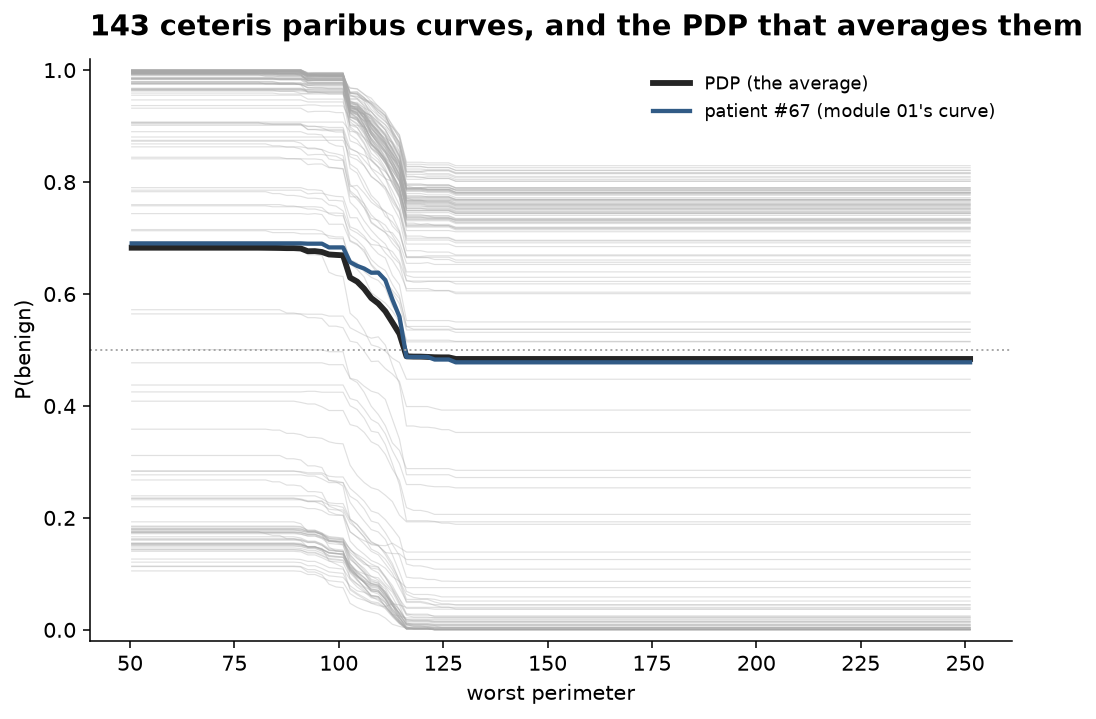

PDP runs from 0.682 down to 0.484


In [3]:
fig, ax = new_figure("143 ceteris paribus curves, and the PDP that averages them")
for i in range(len(ICE)):
    ax.plot(GRID, ICE[i], color=GRAY, linewidth=0.6, alpha=0.35)
ax.plot(GRID, PDP, color=DARK, linewidth=3.0, label="PDP (the average)")
ax.plot(GRID, ICE[instance_idx], color=BLUE, linewidth=2.2,
        label=f"patient #{instance_idx} (module 01's curve)")
ax.axhline(0.5, color=GRAY, linewidth=1.0, linestyle=":")
ax.set_xlabel(feature_names[J])
ax.set_ylabel("P(benign)")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper right", fontsize=9.5, framealpha=0.93, edgecolor="none")
save_figure(fig, "ice_step_1_bundle")
plt.show()

print(f"PDP runs from {PDP.max():.3f} down to {PDP.min():.3f}")

## Step 2 — a prediction we made, and got wrong

Before running this we expected most curves to be **flat**. The reasoning
looked sound: module 03 measures that 71% of held-out real patients sit in a
saturated prediction, pinned near 0 or 1, and a pinned curve has nowhere to
go. So an ICE plot on a confident classifier should be mostly dead lines.

**It is not, and the number is not close.** The histogram below is the range
of each patient's curve. Read it before the text underneath.

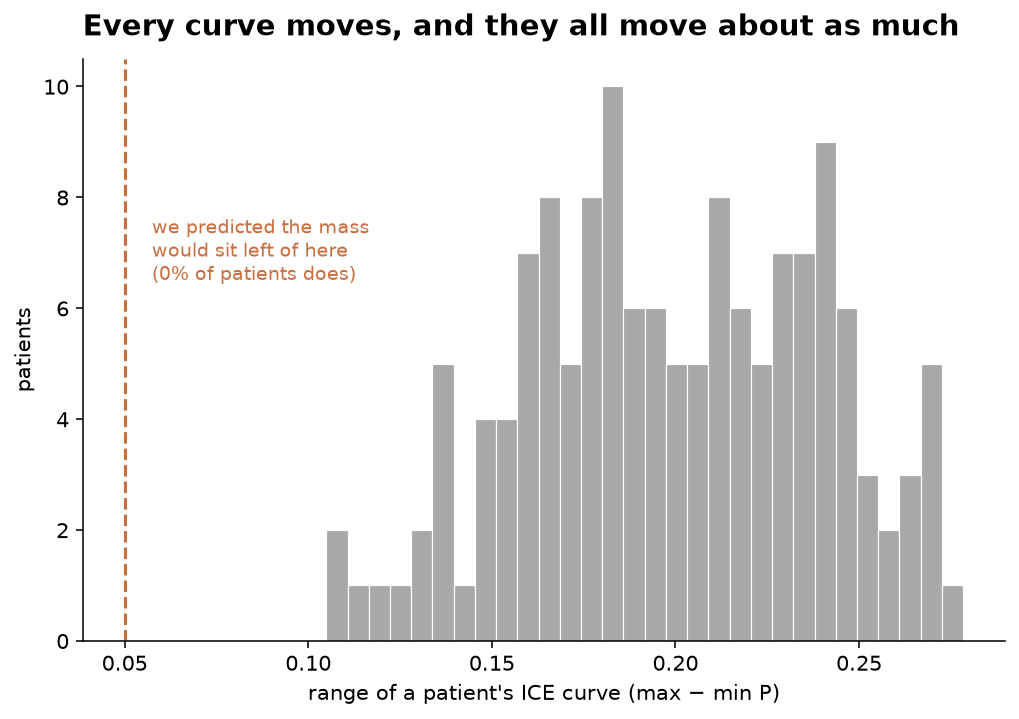

curve range: median 0.199, mean 0.199, min 0.105, max 0.278
flat (range < 0.05): 0 of 143 patients (0%)
  caveat on that zero: the smallest range in the sample is 0.105, 2.1x the threshold we set.
  So '0 of 143' was fixed by the choice of 0.05, not by the data. The
  number that carries information is the median, 0.199.

group                           n   median curve range
borderline |P-0.5| < 0.15       6                0.206
confident  |P-0.5| > 0.30     127                0.195

correlation between confidence and how much the curve moves: -0.09

So the prediction fails on every count. Not one curve is flat. Confident
and borderline patients move by the same amount, and the correlation
between confidence and movement is essentially zero.

Why the reasoning was wrong: module 03's 71% describes real patients AT
THEIR OWN feature values. This sweep drags 'worst perimeter' from 50 to
251 — the full observed range. That is a large enough move to pull even a
confident patient across the

In [4]:
rng = ICE.max(axis=1) - ICE.min(axis=1)
flat = rng < 0.05

fig, ax = new_figure("Every curve moves, and they all move about as much")
ax.hist(rng, bins=30, color=GRAY, edgecolor="white", linewidth=0.6)
ax.axvline(0.05, color=TERRACOTTA, linewidth=1.6, linestyle="--")
ax.annotate(f"we predicted the mass\nwould sit left of here\n({flat.mean():.0%} of patients does)",
            xy=(0.05, ax.get_ylim()[1] * 0.62), xytext=(14, 0),
            textcoords="offset points", fontsize=10, color=TERRACOTTA)
ax.set_xlabel("range of a patient's ICE curve (max − min P)")
ax.set_ylabel("patients")
save_figure(fig, "ice_step_2_flat")
plt.show()

print(f"curve range: median {np.median(rng):.3f}, mean {rng.mean():.3f}, "
      f"min {rng.min():.3f}, max {rng.max():.3f}")
print(f"flat (range < 0.05): {flat.sum()} of {len(rng)} patients ({flat.mean():.0%})")
print(f"  caveat on that zero: the smallest range in the sample is {rng.min():.3f}, "
      f"{rng.min() / 0.05:.1f}x the threshold we set.")
print(f"  So '0 of 143' was fixed by the choice of 0.05, not by the data. The")
print(f"  number that carries information is the median, {np.median(rng):.3f}.")

border = conf < 0.15
confident = conf > 0.30
print(f"\n{'group':<28} {'n':>4} {'median curve range':>20}")
print(f"{'borderline |P-0.5| < 0.15':<28} {border.sum():>4} {np.median(rng[border]):>20.3f}")
print(f"{'confident  |P-0.5| > 0.30':<28} {confident.sum():>4} {np.median(rng[confident]):>20.3f}")
print(f"\ncorrelation between confidence and how much the curve moves: "
      f"{np.corrcoef(conf, rng)[0, 1]:+.2f}")

print("\nSo the prediction fails on every count. Not one curve is flat. Confident")
print("and borderline patients move by the same amount, and the correlation")
print("between confidence and movement is essentially zero.")
print("\nWhy the reasoning was wrong: module 03's 71% describes real patients AT")
print("THEIR OWN feature values. This sweep drags 'worst perimeter' from 50 to")
print("251 — the full observed range. That is a large enough move to pull even a")
print("confident patient across the region where the forest changes its mind.")
print("Saturation is a property of where the patients are, not of where you can")
print("push them.")

## Step 3 — centred ICE

Centring is usually sold as the fix for the problem we just failed to find.
It is still worth doing, because it answers a different question cleanly: not
*where* each patient sits, but *how much each one moves*.

Molnar's definition anchors every curve at the same starting point:

$$\text{ICE}^{(i)}_{\text{centred}}(z) = \hat{f}\big(z, \mathbf{x}^{(i)}_{-j}\big)
  - \hat{f}\big(a, \mathbf{x}^{(i)}_{-j}\big)$$

Now the plot shows *change*, not level, and a patient pinned at 0.98 can be
compared with one pinned at 0.11.

**What to look for.** Whether the curves fan out or stay together.

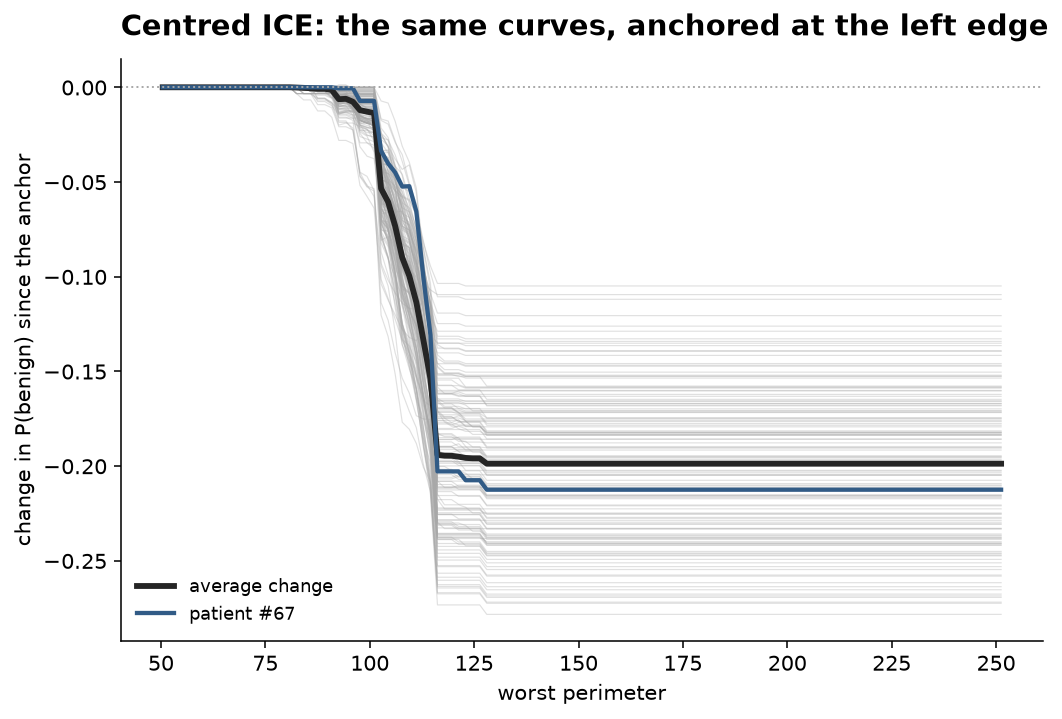

total change from anchor to the right edge:
  median -0.199   5th pct -0.263   95th pct -0.134
  patients who end up HIGHER than they started: 0 of 143


In [5]:
cICE = ICE - ICE[:, [0]]

fig, ax = new_figure("Centred ICE: the same curves, anchored at the left edge")
for i in range(len(cICE)):
    ax.plot(GRID, cICE[i], color=GRAY, linewidth=0.6, alpha=0.35)
ax.plot(GRID, cICE.mean(axis=0), color=DARK, linewidth=3.0, label="average change")
ax.plot(GRID, cICE[instance_idx], color=BLUE, linewidth=2.2, label=f"patient #{instance_idx}")
ax.axhline(0, color=GRAY, linewidth=1.0, linestyle=":")
ax.set_xlabel(feature_names[J])
ax.set_ylabel("change in P(benign) since the anchor")
ax.legend(loc="lower left", fontsize=9.5, framealpha=0.93, edgecolor="none")
save_figure(fig, "ice_step_3_centred")
plt.show()

print(f"total change from anchor to the right edge:")
print(f"  median {np.median(cICE[:, -1]):+.3f}   "
      f"5th pct {np.percentile(cICE[:, -1], 5):+.3f}   "
      f"95th pct {np.percentile(cICE[:, -1], 95):+.3f}")
print(f"  patients who end up HIGHER than they started: "
      f"{(cICE[:, -1] > 0).sum()} of {len(cICE)}")

## Step 4 — what the average hides, measured

This is the argument ICE was invented for. Goldstein et al. (2015) proposed it
precisely because a PDP averages away disagreement: if half the patients go up
and half go down, the average is flat and reports nothing.

The claim is right in general. The question a lecture should ask is whether it
is right *here* — and the honest way to find out is to measure the
disagreement rather than assume it.

**What to look for.** The fraction of patients moving *against* the PDP at each
point on the sweep, and in particular its value where the PDP is steepest.

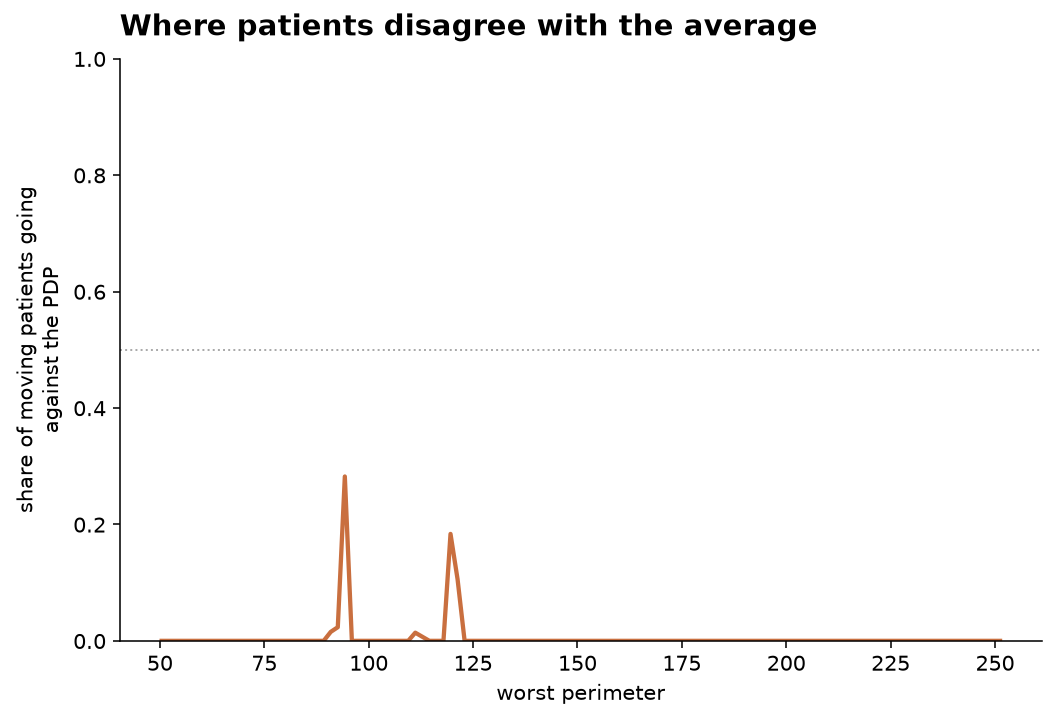

share of moving patients going against the PDP:
  median across the sweep 0%, max 28%
  at the steepest point of the PDP (115): 0%

Second expectation, second failure. Where the PDP is steepest — which is
where a summary would be most misleading — every single moving patient goes
the same way it does. Disagreement appears only in the flat tails, where
nothing much is happening for anyone.

On this model, with this feature, the PDP is an honest summary. There is
almost nothing behind it to hide. That does not make Goldstein et al. wrong;
it makes their warning a hypothesis you have to test on your own data, and
this is what testing it looks like when it comes back negative.


In [6]:
d_pdp = np.gradient(PDP, GRID)
d_ice = np.gradient(ICE, GRID, axis=1)
moving = np.abs(d_ice) > 1e-9
opposite = (np.sign(d_ice) != np.sign(d_pdp)) & moving
frac_opposite = opposite.sum(axis=0) / np.maximum(moving.sum(axis=0), 1)

fig, ax = new_figure("Where patients disagree with the average")
ax.plot(GRID, frac_opposite, color=TERRACOTTA, linewidth=2.2)
ax.axhline(0.5, color=GRAY, linewidth=1.0, linestyle=":")
ax.set_xlabel(feature_names[J])
ax.set_ylabel("share of moving patients going\nagainst the PDP")
ax.set_ylim(0, 1)
save_figure(fig, "ice_step_4_disagreement")
plt.show()

print(f"share of moving patients going against the PDP:")
print(f"  median across the sweep {np.median(frac_opposite):.0%}, "
      f"max {frac_opposite.max():.0%}")
print(f"  at the steepest point of the PDP "
      f"({GRID[np.argmax(np.abs(d_pdp))]:.0f}): "
      f"{frac_opposite[np.argmax(np.abs(d_pdp))]:.0%}")
print("\nSecond expectation, second failure. Where the PDP is steepest — which is")
print("where a summary would be most misleading — every single moving patient goes")
print("the same way it does. Disagreement appears only in the flat tails, where")
print("nothing much is happening for anyone.")
print("\nOn this model, with this feature, the PDP is an honest summary. There is")
print("almost nothing behind it to hide. That does not make Goldstein et al. wrong;")
print("it makes their warning a hypothesis you have to test on your own data, and")
print("this is what testing it looks like when it comes back negative.")

## Step 5 — the same off-manifold bill, now multiplied

Module 01 measured that sweeping `worst perimeter` with `worst radius` frozen
makes 84% of one patient's curve geometrically impossible. An ICE plot runs
that same sweep 143 times.

**What to look for.** The number at the bottom. It is the same instrument
module 03 used on LIME, so the three modules are finally comparable.

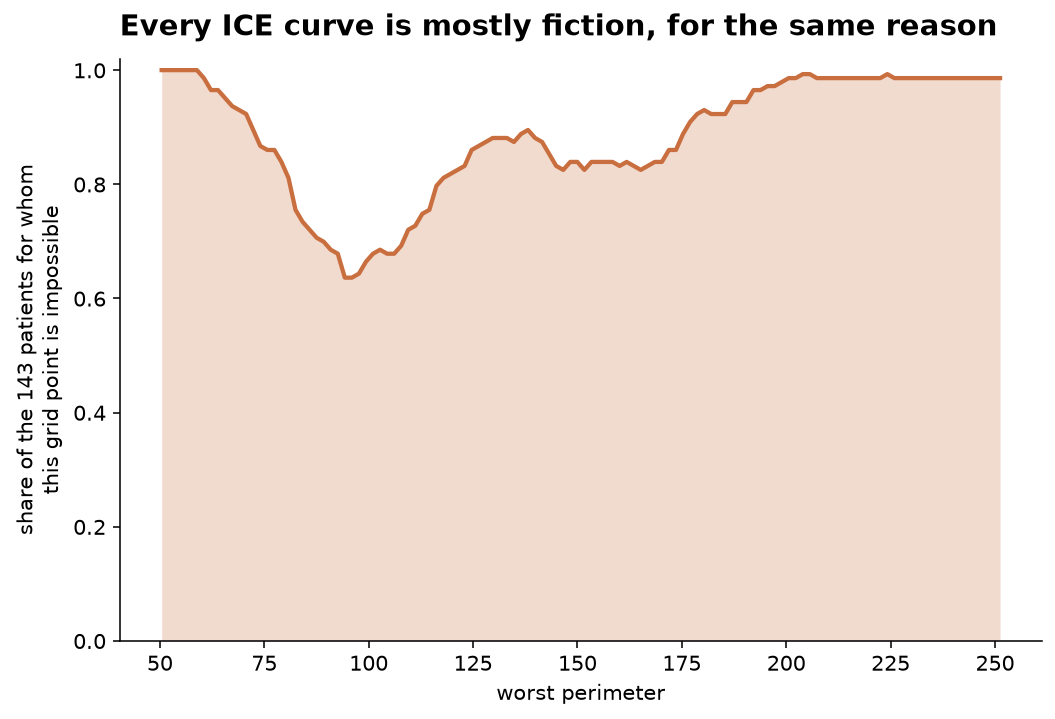

real perimeter/radius ratio: 6.22 to 7.67
of the 17,160 rows this ICE plot fed to the model, 88% are geometrically impossible
patients for whom MORE THAN HALF the curve is impossible: 100%

Resist the urge to line this up against the other modules. An earlier
version of this notebook printed 84% / 88% / 76% as a course-wide table,
and it was wrong twice over:
  - 84 vs 88 is the SWEEP WIDTH, not the method. Run module 01's +/-2.5
    sigma grid on all 143 patients and it is 84% again; run this full-range
    grid on her alone and it is 88%. Going from 1 patient to 143 changes
    the rate by zero.
  - module 03's 76% is a different criterion entirely ('at least one
    negative measurement'), not this envelope. Under this envelope LIME's
    cloud scores higher, so the old table implied LIME was the cleanest of
    the three when it is not.

What is comparable is the habit, not the percentage: every method in this
course evaluates the model on rows the joint distribution excludes. Quot

In [7]:
R = feat_idx["worst radius"]
ratio_real = X_all[:, J] / X_all[:, R]
lo_r, hi_r = ratio_real.min(), ratio_real.max()

ratio_grid = GRID[None, :] / X_test[:, R][:, None]
impossible = (ratio_grid < lo_r) | (ratio_grid > hi_r)

fig, ax = new_figure("Every ICE curve is mostly fiction, for the same reason")
share = impossible.mean(axis=0)
ax.fill_between(GRID, 0, share, color=TERRACOTTA, alpha=0.25, lw=0)
ax.plot(GRID, share, color=TERRACOTTA, linewidth=2.2)
ax.set_xlabel(feature_names[J])
ax.set_ylabel("share of the 143 patients for whom\nthis grid point is impossible")
ax.set_ylim(0, 1.02)
save_figure(fig, "ice_step_5_impossible")
plt.show()

print(f"real perimeter/radius ratio: {lo_r:.2f} to {hi_r:.2f}")
print(f"of the {impossible.size:,} rows this ICE plot fed to the model, "
      f"{impossible.mean():.0%} are geometrically impossible")
print(f"patients for whom MORE THAN HALF the curve is impossible: "
      f"{(impossible.mean(axis=1) > 0.5).mean():.0%}")
print("\nResist the urge to line this up against the other modules. An earlier")
print("version of this notebook printed 84% / 88% / 76% as a course-wide table,")
print("and it was wrong twice over:")
print("  - 84 vs 88 is the SWEEP WIDTH, not the method. Run module 01's +/-2.5")
print("    sigma grid on all 143 patients and it is 84% again; run this full-range")
print("    grid on her alone and it is 88%. Going from 1 patient to 143 changes")
print("    the rate by zero.")
print("  - module 03's 76% is a different criterion entirely ('at least one")
print("    negative measurement'), not this envelope. Under this envelope LIME's")
print("    cloud scores higher, so the old table implied LIME was the cleanest of")
print("    the three when it is not.")
print("\nWhat is comparable is the habit, not the percentage: every method in this")
print("course evaluates the model on rows the joint distribution excludes. Quote")
print("each number with its own grid and its own criterion attached.")

## The four views, side by side

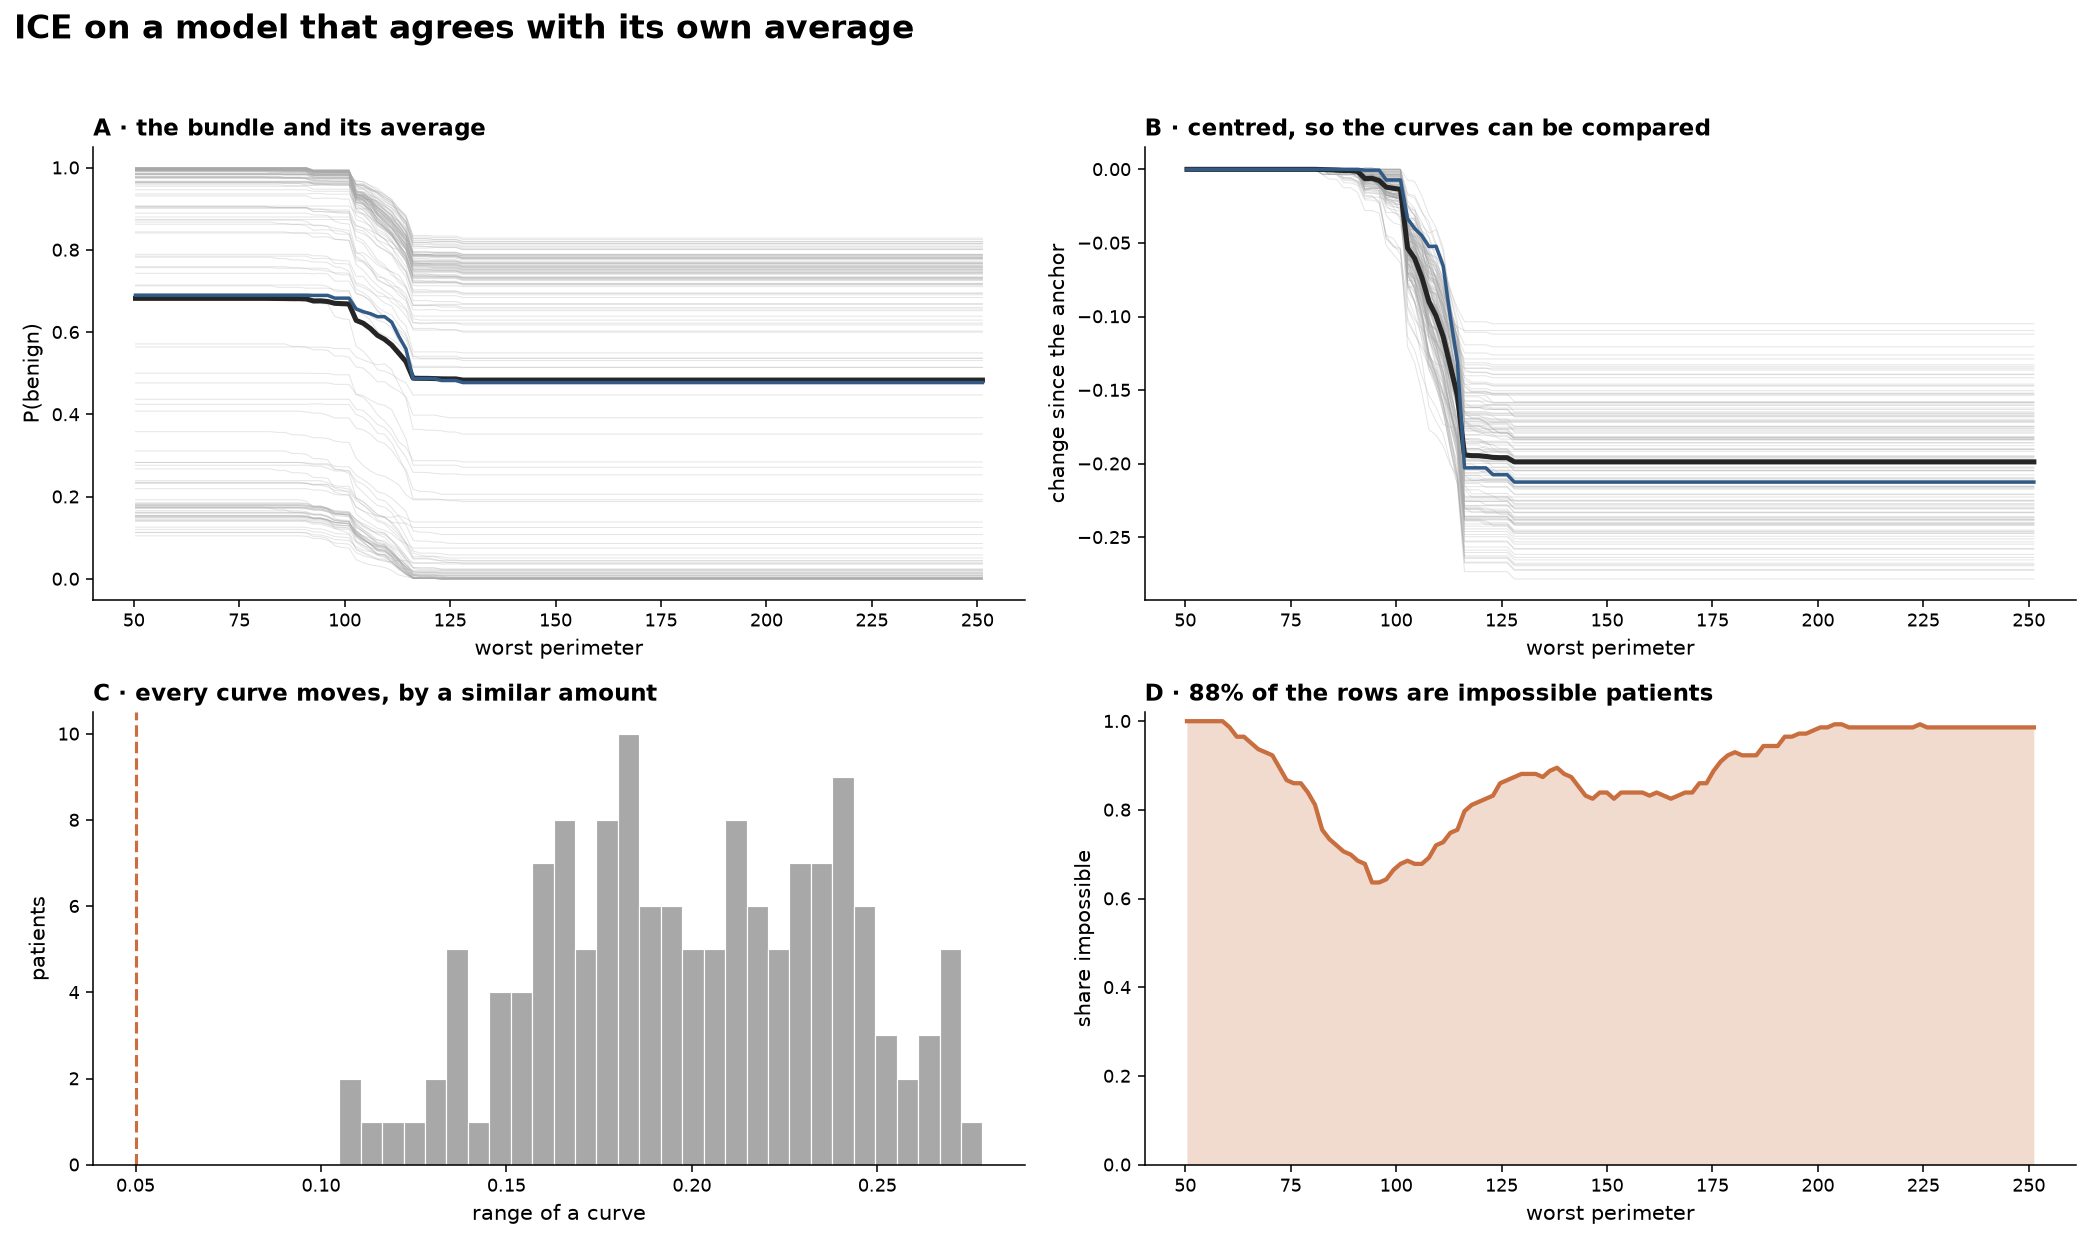

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
panels = [
    ("A · the bundle and its average", ICE, PDP, "P(benign)"),
    ("B · centred, so the curves can be compared", cICE, cICE.mean(axis=0),
     "change since the anchor"),
]
for ax, (t, curves, avg, ylab) in zip(axes.ravel()[:2], panels):
    for i in range(len(curves)):
        ax.plot(GRID, curves[i], color=GRAY, linewidth=0.5, alpha=0.3)
    ax.plot(GRID, avg, color=DARK, linewidth=2.6)
    ax.plot(GRID, curves[instance_idx], color=BLUE, linewidth=1.8)
    ax.set_title(t, loc="left", fontsize=12, fontweight="bold")
    ax.set_xlabel(feature_names[J]); ax.set_ylabel(ylab)

axes[1, 0].hist(rng, bins=30, color=GRAY, edgecolor="white", linewidth=0.6)
axes[1, 0].axvline(0.05, color=TERRACOTTA, linewidth=1.6, linestyle="--")
axes[1, 0].set_title("C · every curve moves, by a similar amount", loc="left",
                     fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("range of a curve"); axes[1, 0].set_ylabel("patients")

axes[1, 1].fill_between(GRID, 0, share, color=TERRACOTTA, alpha=0.25, lw=0)
axes[1, 1].plot(GRID, share, color=TERRACOTTA, linewidth=2.2)
axes[1, 1].set_title(f"D · {impossible.mean():.0%} of the rows are impossible patients",
                     loc="left", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel(feature_names[J]); axes[1, 1].set_ylabel("share impossible")
axes[1, 1].set_ylim(0, 1.02)

for ax in axes.ravel():
    ax.tick_params(labelsize=9)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
fig.suptitle("ICE on a model that agrees with its own average", x=0.007, ha="left",
             fontsize=17, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
save_figure(fig, "ice_combined")
plt.show()

## What to carry to the next module

ICE adds exactly one thing to module 01, and it is worth having: it shows you
**whether the patients agree**. A PDP cannot, by construction, and reporting
one without the spread behind it is reporting a mean with no variance.

This notebook made two predictions about what that spread would show, and both
were wrong. We expected most curves to be flat, because the model is confident
about most patients; **not one of the 143 is flat**. We expected the average to
be hiding disagreement, because that is what ICE was invented to reveal; where
the PDP is steepest, **no moving patient disagrees with it**.

Both are kept here rather than quietly deleted, because the useful lesson is
not the finding — it is that ICE is the instrument that told us. Without the
bundle we would have shown a PDP and had no idea whether it was a fair summary
or a mirage. Here it happens to be fair. On the next dataset it may not be, and
the only way to know is to draw the curves.

What did survive is the bill from module 01, arriving multiplied: 88% of the
rows this plot fed to the model are geometrically impossible, and there is no
patient for whom less than half the curve is fiction.

Module 03 takes the next step: instead of moving one feature at a time, move
all thirty at once and fit a model to the result.

In [9]:
print("Technical companion, with d-ICE and the robustness checks: ice_internals.ipynb")

Technical companion, with d-ICE and the robustness checks: ice_internals.ipynb
